In [6]:
import os
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    Conv2D,
    Conv3D,
    MaxPooling2D,
    BatchNormalization,
    Activation
)
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [7]:
dataset_path = r"C:\Users\Abhyuday\Documents\MRI-Based-Brain-Tumor-Detection-and-Classification-with-Deep-Learning-and-neural-networks\Dataset\Training"
classes = os.listdir(dataset_path)

In [8]:
enc = OneHotEncoder()
enc.fit([[0], [1], [2], [3]]) 
def names(number):
    if(number == 0):
        return classes[0]
    elif(number == 1):
        return classes[1]
    elif(number == 2):
        return classes[2]
    elif(number == 3):
        return classes[3]

In [9]:
trainData = []
trainLabel = []

dim = (150, 150)
trainPath = r"C:\Users\Abhyuday\Documents\MRI-Based-Brain-Tumor-Detection-and-Classification-with-Deep-Learning-and-neural-networks\Dataset\Training"

classes = os.listdir(trainPath)
num_classes = len(classes)

index = 0
for dir in classes:
    subDir = os.path.join(trainPath, dir)
    
    for file in os.listdir(subDir):
        imgFullPath = os.path.join(subDir, file)
        img = Image.open(imgFullPath).convert("RGB")
        img = img.resize(dim)
        img = np.array(img)

        trainData.append(img)
        trainLabel.append(index)

    print(f"Class {index}: {dir}")
    index += 1

trainData = np.array(trainData)
trainLabel = to_categorical(trainLabel, num_classes=num_classes)

print(trainData.shape)
print(trainLabel.shape)

Class 0: glioma_tumor
Class 1: meningioma_tumor
Class 2: no_tumor
Class 3: pituitary_tumor
(2870, 150, 150, 3)
(2870, 4)


In [10]:
testData = []
testLabel = []

dim = (150, 150)
testPath = r"C:\Users\Abhyuday\Documents\MRI-Based-Brain-Tumor-Detection-and-Classification-with-Deep-Learning-and-neural-networks\Dataset\Testing"

# IMPORTANT: same class order as training
classes = sorted(os.listdir(testPath))
num_classes = len(classes)

index = 0
for dir in classes:
    subDir = os.path.join(testPath, dir)

    for file in os.listdir(subDir):
        imgFullPath = os.path.join(subDir, file)

        img = Image.open(imgFullPath).convert("RGB")
        img = img.resize(dim)
        img = np.array(img)

        testData.append(img)
        testLabel.append(index)

    print(f"Class {index}: {dir}")
    index += 1

testData = np.array(testData)
testLabel = to_categorical(testLabel, num_classes=num_classes)

print(testData.shape)
print(testLabel.shape)

Class 0: glioma_tumor
Class 1: meningioma_tumor
Class 2: no_tumor
Class 3: pituitary_tumor
(394, 150, 150, 3)
(394, 4)


In [11]:
model = Sequential()

model.add(Conv2D(64, (5,5), padding='same', activation='relu',
                 input_shape=(150, 150, 3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.30))

model.add(Conv2D(128, (2,2), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.30))

model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4, activation='softmax'))

optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

epochs = 40
batch_size = 40

datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True
)

datagen.fit(trainData)

epochs = 40
batch_size = 40

history = model.fit(
    datagen.flow(trainData, trainLabel, batch_size=batch_size),
    steps_per_epoch=trainData.shape[0] // batch_size,
    epochs=epochs,
    validation_data=(testData / 255.0, testLabel)
)

C:\Users\Abhyuday\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.4325 - loss: 1.2841 - val_accuracy: 0.2919 - val_loss: 1.5970
Epoch 2/40
 1/71 ━━━━━━━━━━━━━━━━━━━━ 2:35 2s/step - accuracy: 0.6500 - loss: 0.8616

C:\Users\Abhyuday\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.6500 - loss: 0.8616 - val_accuracy: 0.2919 - val_loss: 1.6159
Epoch 3/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.5961 - loss: 0.9189 - val_accuracy: 0.2919 - val_loss: 1.6268
Epoch 4/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.6250 - loss: 0.8207 - val_accuracy: 0.2919 - val_loss: 1.5654
Epoch 5/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.6784 - loss: 0.7336 - val_accuracy: 0.3452 - val_loss: 1.8107
Epoch 6/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.6250 - loss: 0.8213 - val_accuracy: 0.3452 - val_loss: 1.7890
Epoch 7/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.7155 - loss: 0.6558 - val_accuracy: 0.3807 - val_loss: 1.5553
Epoch 8/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.7250 - loss: 0.9537 - val_accuracy: 0.3756 - val_loss: 1.5439
Epoch 9/40
71/71 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.7594 - loss: 0.5808 - val_accuracy: 0.3807 - val_loss: 1.

In [13]:
model.save("classification.keras")

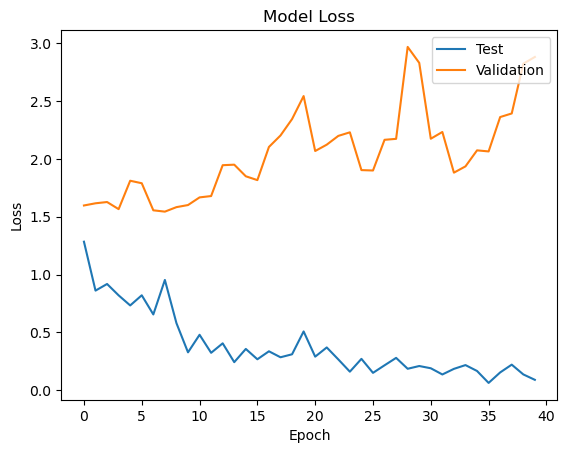

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Test', 'Validation'], loc='upper right')
plt.show()

99.505875% Confidence This Is pituitary_tumor


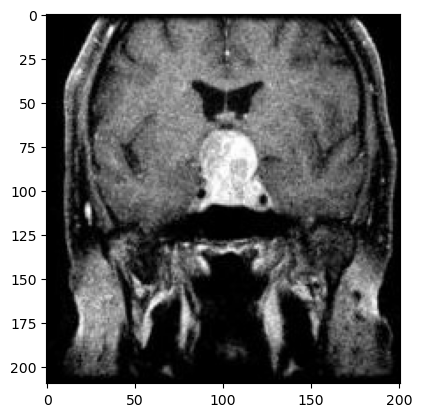

In [30]:
img = Image.open(r"C:\Users\Abhyuday\Documents\MRI-Based-Brain-Tumor-Detection-and-Classification-with-Deep-Learning-and-neural-networks\Dataset\Testing\pituitary_tumor\image(37).jpg")
x = np.array(img.resize(dim))
x = x.reshape(1,150,150,3)
answ = model.predict_on_batch(x)
classification = np.where(answ == np.amax(answ))[1][0]
imshow(img)
print(str(answ[0][classification]*100) + '% Confidence This Is ' + names(classification))